<a href="https://colab.research.google.com/github/Shiv07ansh/AlzhAImers/blob/experiment%2Fnew_dense_layers/Model/Training_TinyLM_for_Esp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q tensorflow==2.15.0 pandas scikit-learn #numpy==1.26.4

In [2]:
from google.colab import files
uploaded = files.upload()

Saving second_draft.csv to second_draft (1).csv


In [3]:
import pandas as pd
import io

filename = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded[filename]))
df.head()

,text,label
0,am I supposed to take a dose,ask_med_details
1,am I supposed to take any pills,ask_med_details
2,am I supposed to take any pills right now,ask_med_details
3,am I supposed to take anything now,ask_med_details
4,am I taking any pills at the moment,ask_med_details


In [14]:
#Import required libraries
##-----------------------##
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional, GlobalAveragePooling1D # Added GAP1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split


texts = df['text'].astype(str).tolist()
labels = df['label'].astype(str).tolist()

# Tokenize text
tokenizer = Tokenizer(num_words=1500, oov_token="<OOV>") #Decidedly through trial and error 1500 works best right now
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
max_len = 15 #Based on the dataset
X = pad_sequences(sequences, maxlen=max_len)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)
num_classes = len(le.classes_)

# Correct vocab_size for Embedding layer
vocab_size = tokenizer.num_words + 1 #1500 words + 1 for OOV token

embedding_output_dim = 150 # Through trial and error going from 128 to 196 to 150


model = Sequential([
    tf.keras.Input(shape=(15,), dtype='int32', name="input_ids"),
    Embedding(input_dim=vocab_size, output_dim=embedding_output_dim, input_length=max_len),
    GlobalAveragePooling1D(),                      # 💡 Light-weight alternative to GRU
    Dense(94, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])



model.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=['accuracy'])

# Print model summary to see the number of parameters
model.summary()

# Split data (already good)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Early stopping (already good)
es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30, # Max epochs, but early stopping will handle it
    batch_size=16,
    verbose=1,
    callbacks=[es]
)


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 15, 150)           225150    
                                                                 
 global_average_pooling1d_1  (None, 150)               0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dense_2 (Dense)             (None, 94)                14194     
                                                                 
 dropout_1 (Dropout)         (None, 94)                0         
                                                                 
 dense_3 (Dense)             (None, 8)                 760       
                                                                 
Total params: 240104 (937.91 KB)
Trainable params: 240104 (937.91 KB)
Non-trainable params: 0 (0.00 Byte)
______________

In [18]:
model.save("alz.h5")

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [21]:
#Evaluate details

model = tf.keras.models.load_model("alz.h5")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
print(interpreter.get_input_details())

[{'name': 'serving_default_input_ids:0', 'index': 0, 'shape': array([ 1, 15], dtype=int32), 'shape_signature': array([-1, 15], dtype=int32), 'dtype': <class 'numpy.int32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [23]:
import tensorflow as tf

model = tf.keras.models.load_model("alz.h5")

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# No optimizations or quantization
# Keep input/output as is (e.g., int32 input → int32 output or softmax float)
tflite_model = converter.convert()

with open("model_int32.tflite", "wb") as f:
    f.write(tflite_model)


In [24]:
#Confirming the quantization

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
print(interpreter.get_input_details())


[{'name': 'serving_default_input_ids:0', 'index': 0, 'shape': array([ 1, 15], dtype=int32), 'shape_signature': array([-1, 15], dtype=int32), 'dtype': <class 'numpy.int32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [25]:
# 1. Run xxd to generate the C array:
!xxd -i model_int32.tflite > model_data.cc

# 2. (Optional) Preview the first few lines:
!head -n 20 model_data.cc

unsigned char model_int32_tflite[] = {
  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x90, 0x00, 0x00, 0x00, 0xe8, 0x00, 0x00, 0x00, 0xa8, 0xa9, 0x0e, 0x00,
  0xb8, 0xa9, 0x0e, 0x00, 0x68, 0xb0, 0x0e, 0x00, 0x03, 0x00, 0x00, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x10, 0x00, 0x00, 0x00, 0x00, 0x00, 0x0a, 0x00,
  0x10, 0x00, 0x0c, 0x00, 0x08, 0x00, 0x04, 0x00, 0x0a, 0x00, 0x00, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00, 0x38, 0x00, 0x00, 0x00,
  0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76, 0x69, 0x6e, 0x67, 0x5f,
  0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00, 0x01, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x98, 0xff, 0xff, 0xff, 0x0b, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x07, 0x00, 0x00, 0x00, 0x64, 0x65, 0x6e, 0x73,
  0x65, 0x5f, 0x33, 0x00, 0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00,

In [26]:
from google.colab import files
files.download('model_data.cc')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
#Generate vocab.h
import json
# Assuming tokenizer is already fitted
word_index = tokenizer.word_index
filtered_index = {k: v for k, v in word_index.items() if v < 1500}

with open("word_index.json", "w") as f:
    json.dump(filtered_index, f)

from google.colab import files
files.download('word_index.json')




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import json

# Load the word index from a JSON file
with open("word_index.json", "r") as f:
    word_index = json.load(f)

# Open the output header file
with open("vocab.h", "w") as f:
    f.write("// Auto-generated vocab header\n")
    f.write("#ifndef VOCAB_H\n#define VOCAB_H\n\n")
    f.write("#include <map>\n#include <string>\n\n")

    f.write("static const std::map<std::string, int> vocab = {\n")
    for word, idx in word_index.items():
        escaped_word = word.replace('"', '\\"')  # escape any quotes
        f.write(f'    {{"{escaped_word}", {idx}}},\n')
    f.write("};\n\n")

    f.write("#endif // VOCAB_H\n")

from google.colab import files
files.download('vocab.h')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np # Import numpy if not already imported

# y_true and y_pred are your true and predicted labels for the validation set
# Use y_val as the true labels
y_true = y_val

# Make predictions on the validation set
# model.predict returns probabilities, so use np.argmax to get the predicted class index
y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)

# Now y_true and y_pred are defined and contain the labels and predictions for the validation set
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

9/9 [==============================] - 0s 2ms/step
[[28  0  0  0  0  0  0  0]
 [ 1 29  0  0  0  0  0  0]
 [ 0  0 24  0  0  0  0  0]
 [ 0  0  0 39  0  0  0  0]
 [ 0  0  0  0 39  0  0  0]
 [ 0  0  1  1  0 44  0  0]
 [ 0  0  0  0  1  2 39  0]
 [ 0  0  0  0  0  0  1 31]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        28
           1       1.00      0.97      0.98        30
           2       0.96      1.00      0.98        24
           3       0.97      1.00      0.99        39
           4       0.97      1.00      0.99        39
           5       0.96      0.96      0.96        46
           6       0.97      0.93      0.95        42
           7       1.00      0.97      0.98        32

    accuracy                           0.97       280
   macro avg       0.98      0.98      0.98       280
weighted avg       0.98      0.97      0.97       280



In [ ]:
def sequence_to_text(sequence, tokenizer):
    reverse_word_map = dict(map(reversed, tokenizer.word_index.items()))
    return ' '.join([reverse_word_map.get(idx, '<PAD>') for idx in sequence if idx != 0])

print("--- Misclassified Prompts ---")
misclassified_count = 0
for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        misclassified_count += 1
        prompt_text = sequence_to_text(X_val[i], tokenizer)
        print(f"  Prompt: '{prompt_text}'")
        print(f"  True Class: {le.classes_[y_true[i]]} (Label: {y_true[i]})")
        print(f"  Predicted Class: {le.classes_[y_pred[i]]} (Label: {y_pred[i]})")
        print("-" * 30)

In [ ]:
#-----------------Check Class Labels-----------------------#


class_labels = sorted(df['label'].unique())

# Create mappings
class_to_index = {label: idx for idx, label in enumerate(class_labels)}
index_to_class = {idx: label for label, idx in class_to_index.items()}

print("Index to Class mapping:")
for idx, label in index_to_class.items():
    print(f"{idx}: {label}")

Index to Class mapping:
0: ask_med_details
1: ask_schedule
2: ask_time
3: confirm_taken
4: deny_taken
5: irrelevant
6: notify_sos
7: remind_later


In [ ]:
import numpy as np
def predict_label(prompt):
    seq = tokenizer.texts_to_sequences([prompt])
    pad_seq = pad_sequences(seq, maxlen=max_len)
    pred = np.argmax(model.predict(pad_seq), axis=1)
    return le.inverse_transform(pred)[0]

# Examples
print(predict_label("whats the weather"))
print(predict_label("Do you know the time this afternoon"))
print(predict_label("Yes, I took them"))
print(predict_label("No, I haven’t taken them"))
print(predict_label("When should I take my meds?"))
print(predict_label("is it time for my pills yet"))
print(predict_label("what medicines should I take"))
print(predict_label("remind me agian in 10 minutes"))
print(predict_label("I will take them later"))
print(predict_label("now??"))
print(predict_label("what"))

1/1 [==============================] - 0s 30ms/step
irrelevant
1/1 [==============================] - 0s 21ms/step
ask_time
1/1 [==============================] - 0s 20ms/step
confirm_taken
1/1 [==============================] - 0s 22ms/step
deny_taken
1/1 [==============================] - 0s 22ms/step
ask_med_details
1/1 [==============================] - 0s 24ms/step
ask_time
1/1 [==============================] - 0s 21ms/step
ask_med_details
1/1 [==============================] - 0s 24ms/step
remind_later
1/1 [==============================] - 0s 22ms/step
remind_later
1/1 [==============================] - 0s 23ms/step
irrelevant
1/1 [==============================] - 0s 22ms/step
irrelevant


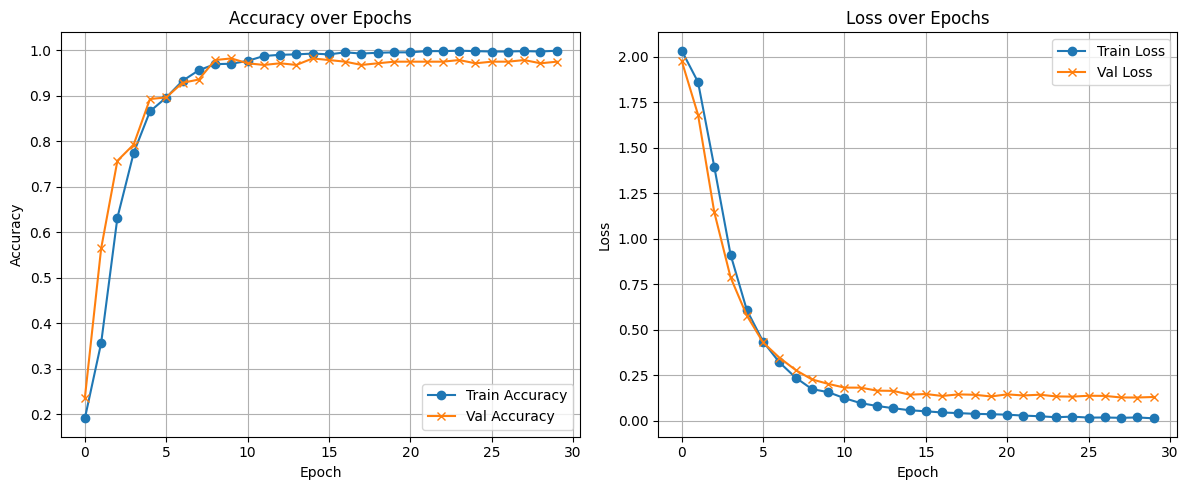

In [15]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='x')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='x')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

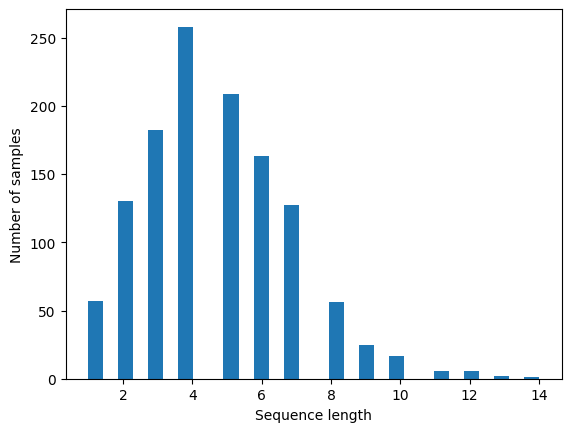

Max length: 14
Median length: 4.0
90th percentile length: 7.0


In [ ]:
sequences = tokenizer.texts_to_sequences(texts)
lengths = [len(seq) for seq in sequences]

import matplotlib.pyplot as plt
plt.hist(lengths, bins=30)
plt.xlabel('Sequence length')
plt.ylabel('Number of samples')
plt.show()

print(f"Max length: {max(lengths)}")
print(f"Median length: {np.median(lengths)}")
print(f"90th percentile length: {np.percentile(lengths, 90)}")

In [16]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 15, 150)           225150    
                                                                 
 global_average_pooling1d_1  (None, 150)               0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dense_2 (Dense)             (None, 94)                14194     
                                                                 
 dropout_1 (Dropout)         (None, 94)                0         
                                                                 
 dense_3 (Dense)             (None, 8)                 760       
                                                                 
Total params: 240104 (937.91 KB)
Trainable params: 240104 (937.91 KB)
Non-trainable params: 0 (0.00 Byte)
______________

In [ ]:
text = ["Did I take my morning medicine?"]

# Convert text to sequence of integers (word indexes)
seq = tokenizer.texts_to_sequences(text)

# Pad sequence to max_len
padded_seq = pad_sequences(seq, maxlen=max_len, padding='post')

print(padded_seq)

[[59  2 18  3 63 23  0  0  0  0  0  0  0  0  0]]


In [ ]:
def predict_label(text):
    seq = tokenizer.texts_to_sequences([text])
    padded_seq = pad_sequences(seq, maxlen=max_len, padding='post')
    interpreter.set_tensor(input_details[0]['index'], padded_seq.astype(input_details[0]['dtype']))
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    pred_index = np.argmax(output, axis=1)[0]
    pred_label = le.inverse_transform([pred_index])[0]
    return pred_label

# Test prompt
prompt = "	Don't forget your medication."
print("Prompt:", prompt)
print("Predicted label:", predict_label(prompt))

Prompt: 	Don't forget your medication.
Predicted label: confirm_taken


In [ ]:
print(df['label'].value_counts())

label
notify_take_meds        10
ask_intake_status       10
confirm_taken           10
deny_taken              10
delay_intake            10
ask_medicine_time       10
delay_request           10
ask_time_context        10
ask_schedule_context    10
irrelevant              10
Name: count, dtype: int64


In [ ]:
original_labels = le.classes_
print("Mapping of integer labels to original text labels:")
for i, label_name in enumerate(original_labels):
    print(f"Integer Label {i}: {label_name}")

Mapping of integer labels to original text labels:
Integer Label 0: ask_med_details
Integer Label 1: ask_schedule
Integer Label 2: ask_time
Integer Label 3: confirm_taken
Integer Label 4: deny_taken
Integer Label 5: irrelevant
Integer Label 6: notify_sos
Integer Label 7: remind_later
